# Your trading record: what an exchange does not show you

**In short.** An exchange lists what you bought and sold. It does not say whether you
tend to buy after a rise, whether you sell near the bottom of the week, or whether all
that trading beat simply holding. Those can be worked out from the trade list and
hourly prices. This notebook shows how, and checks that the method finds a habit when
there is one and stays quiet when there is none.

**The traders here are invented.** Two made-up people trade Solana on real hourly
prices. One **chases**: buys after a strong day, sells after a weak one. The other
trades at **random** hours. Same number of trades, same sizes. Only the timing
differs. Nothing in this notebook comes from a real account.

| Step | What it does | Code |
|---|---|---|
| 1 | Cost, break-even and gain | `radar.models.ledger` |
| 2 | Trading against holding | `radar.models.ledger` |
| 3 | What the price did around each trade | `radar.analytics.trading` |
| 4 | Is the habit real or luck? | `radar.analytics.trading` |

The same code builds the "Your record" page of the app from a Binance history.

Rebuild with `uv run python backend/scripts/build_notebooks.py 06_trading_record`.

In [1]:
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.analytics import trading
from radar.models import ledger
from radar.notebooks import ACCENT, BUY, INK, MUTED, SELL, use_style
from radar.pipelines import research
from radar.providers import binance_public

use_style()
ASSET = "SOL"
START, END = datetime(2023, 1, 1, tzinfo=UTC), datetime(2026, 10, 1, tzinfo=UTC)
with binance_public.reader() as source:
    bars, _ = research.load_binance([ASSET + "USDT"], source, START, END)[ASSET + "USDT"]
bars = bars.loc["2023-01-01":"2026-09-30"]
TRADERS = {
    "chaser": trading.made_up_trades(bars, ASSET, chases=True, seed=1),
    "random": trading.made_up_trades(bars, ASSET, chases=False, seed=1),
}
price_now = float(bars["close"].iloc[-1])
print(f"{len(bars):,} hourly prices, {bars.index[0].date()} to {bars.index[-1].date()}")
for name, entries in TRADERS.items():
    print(f"{name}: {len(entries)} trades")

32,855 hourly prices, 2023-01-01 to 2026-09-30
chaser: 119 trades
random: 119 trades


## The data: the same market, two ways of trading it

Green marks are purchases, red marks are sales.

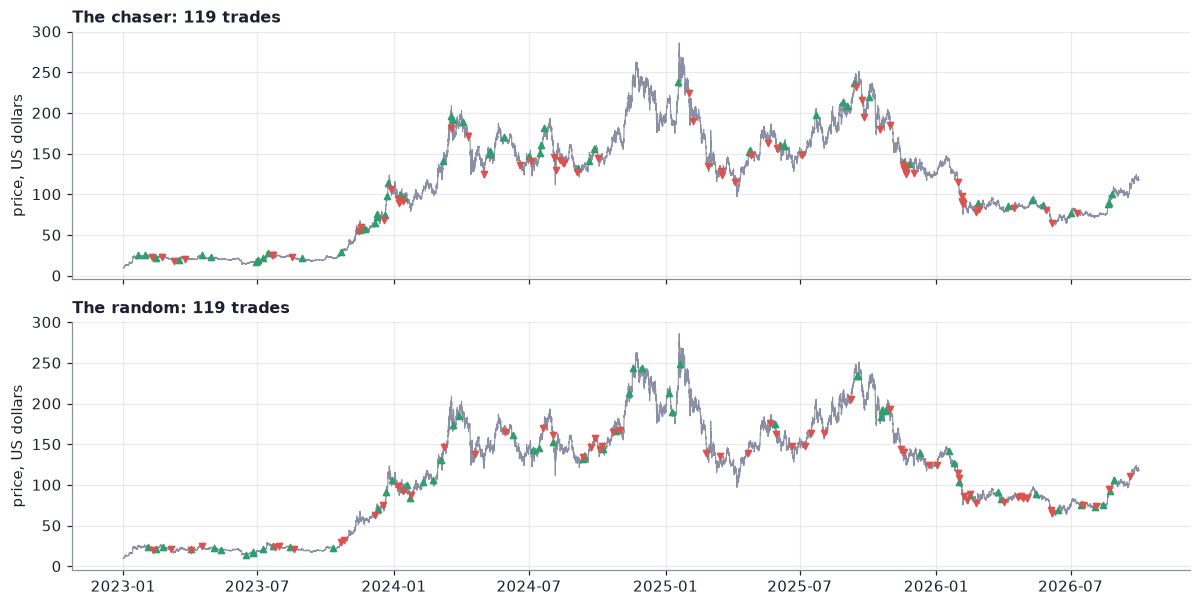

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
for ax, (name, entries) in zip(axes, TRADERS.items()):
    ax.plot(bars.index, bars["close"], color=MUTED, lw=0.7)
    for kind, colour, marker in (("buy", BUY, "^"), ("sell", SELL, "v")):
        chosen = [e for e in entries if e.kind == kind]
        prices = [e.dollars / abs(e.units) for e in chosen]
        ax.scatter([e.at for e in chosen], prices, color=colour, marker=marker, s=16, zorder=3)
    ax.set(title=f"The {name}: {len(entries)} trades", ylabel="price, US dollars")
fig.tight_layout()

## Step 1. Cost, break-even and gain

Cost is kept by the **average method**: every unit still held costs the average of
what was paid for the units still held. That average is also the **break-even
price**. Selling takes the gain or loss against it.

In [3]:
rows = []
for name, entries in TRADERS.items():
    now = ledger.standing(entries)[ASSET]
    rows.append(
        {
            "trader": name,
            "units held": now.units,
            "break-even price": now.average_cost,
            "price now": price_now,
            "gain taken by selling": now.realised,
            "gain on what is held": (price_now - now.average_cost) * now.units,
        }
    )
pd.DataFrame(rows).set_index("trader")

,units held,break-even price,price now,gain taken by selling,gain on what is held
trader,,,,,
chaser,4.29,89.66,118.12,821.33,122.03
random,1.78,88.49,118.12,194.58,52.86


## Step 2. Trading against holding

The fair comparison is with **the same new money, put in at the same times, never
sold**. Money from a sale that pays for a later purchase is not new money.

,put_in,as_traded,if_held,difference
chaser,798.06,"1,741.42","4,304.21","-2,562.79"
random,772.35,"1,019.79","4,596.36","-3,576.57"


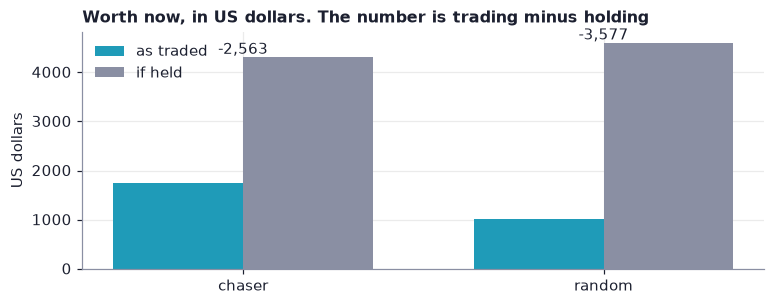

In [4]:
compared = {n: ledger.against_holding(e, ASSET, price_now) for n, e in TRADERS.items()}
fig, ax = plt.subplots(figsize=(8, 2.8))
names = list(compared)
width = 0.36
ax.bar(np.arange(2) - width / 2, [compared[n].as_traded for n in names], width, color=ACCENT, label="as traded")
ax.bar(np.arange(2) + width / 2, [compared[n].if_held for n in names], width, color=MUTED, label="if held")
for i, name in enumerate(names):
    gap = compared[name].difference
    ax.text(i, max(compared[name].as_traded, compared[name].if_held), f"{gap:+,.0f}", ha="center", va="bottom")
ax.set_xticks(range(2), names)
ax.legend()
ax.set(title="Worth now, in US dollars. The number is trading minus holding", ylabel="US dollars")
pd.DataFrame({n: c.model_dump() for n, c in compared.items()}).T.drop(columns="asset")

## Step 3. What the price did around each trade

For every trade three things are read from the hourly prices:

- **the day before**: how far the price had moved in the 24 hours up to the trade;
- **place in the week**: where the trade's price sat in the range of the week before
  it, from 0 (the week's low) to 1 (the week's high);
- **the week after**: what the price did next. This is hindsight, shown as a record.

Each is averaged over the trades, weighted by the money in each, and set beside the
same figure for **any hour** of the period.

In [5]:
contexts = {n: trading.context(e, bars, ASSET) for n, e in TRADERS.items()}
usual = trading.usual(bars, pd.Timestamp(bars.index[0]))
rows = []
for name, table in contexts.items():
    for kind in ("buy", "sell"):
        found = trading.habit(table, kind)
        rows.append(
            {
                "trader": name,
                "trade": kind,
                "trades": found.trades,
                "day before, %": found.before_day * 100,
                "place in the week": found.place,
                "week after, %": found.after_week * 100,
            }
        )
rows.append(
    {
        "trader": "any hour",
        "trade": "",
        "trades": usual.hours,
        "day before, %": usual.before_day * 100,
        "place in the week": usual.place,
        "week after, %": usual.after_week * 100,
    }
)
habits = pd.DataFrame(rows).set_index(["trader", "trade"])
habits

trades  day before, %  place in the week  week after, %
trader   trade                                                         
chaser   buy        60           6.98               0.78           2.46
         sell       59          -5.76               0.31           2.59
random   buy        60          -0.12               0.52           1.31
         sell       59          -0.06               0.51           2.39
any hour         32687           0.26               0.52           1.70

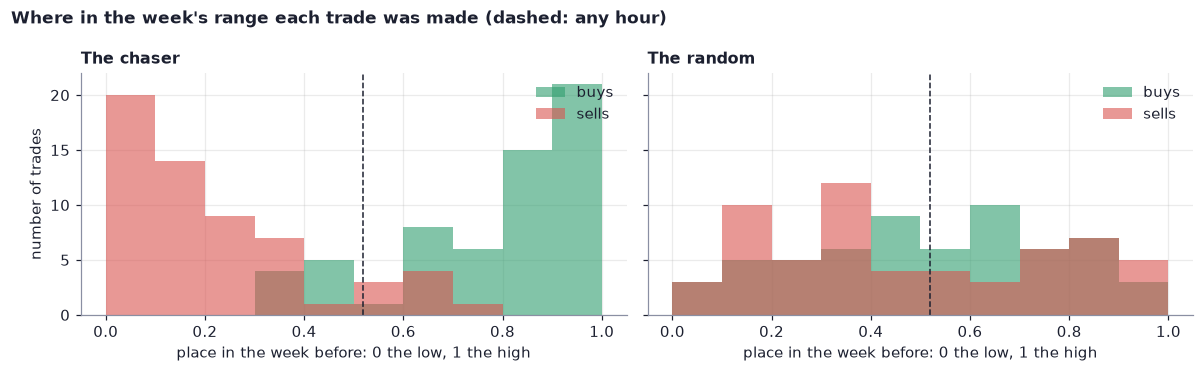

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
edges = np.linspace(0, 1, 11)
for ax, (name, table) in zip(axes, contexts.items()):
    for kind, colour in (("buy", BUY), ("sell", SELL)):
        part = table[table["kind"] == kind]
        ax.hist(part["place"], bins=edges, color=colour, alpha=0.6, label=f"{kind}s")
    ax.axvline(usual.place, color=INK, lw=1, ls="--")
    ax.set(title=f"The {name}", xlabel="place in the week before: 0 the low, 1 the high")
    ax.legend()
axes[0].set_ylabel("number of trades")
fig.suptitle("Where in the week's range each trade was made (dashed: any hour)", x=0.01, ha="left", weight="bold")
fig.tight_layout()

## Step 4. Is the habit real, or luck?

Sixty trades made at random hours would not land exactly on the usual place either.
So the same number of trades is drawn at random hours 2,000 times. A habit is called
**unusual** only when the trader's average falls outside 95% of those draws, and
never on fewer than 10 trades.

In [7]:
rows = []
for name, table in contexts.items():
    for kind in ("buy", "sell"):
        rows.append(
            {
                "trader": name,
                "trade": kind,
                "place in the week": trading.habit(table, kind).place,
                "any hour": usual.place,
                "unusual": trading.place_is_unusual(table, kind, bars),
            }
        )
verdict = pd.DataFrame(rows).set_index(["trader", "trade"])
verdict

place in the week  any hour  unusual
trader trade                                      
chaser buy                 0.78      0.52     True
       sell                0.31      0.52     True
random buy                 0.52      0.52    False
       sell                0.51      0.52    False

## What this shows

- **The method finds a habit when there is one.** The chaser's purchases came after a
  day that had risen 7% and sat at 0.78 of the week's range; the sales came after a day
  down 6%, at 0.31. Both are flagged as unusual.
- **It stays quiet when there is none.** The random trader's purchases and sales sat at
  0.52 and 0.51, the same as any hour, and neither is flagged.
- **Both invented traders ended far behind holding.** Solana rose over these years, and
  each of them sold half of what they held, sixty times. In a rising market that costs
  more than any timing gains. This is the figure an exchange never shows.
- **A realised gain is not the same as doing well.** The chaser took 821 dollars of
  gain by selling and still ended 2,563 dollars behind holding.

## What it means for the app

The "Your record" page shows these same figures for a real account: break-even price,
gain taken and gain still open, trading against holding, and what the price was doing
around the purchases and the sales, with the habit flagged only when it is beyond luck.
It describes what happened. It does not say what to do next.

## Limits

- "The week after" is hindsight. It records what followed past trades and predicts
  nothing about the next one.
- Coins that arrived from outside the exchange have no known cost; they take the market
  price of the day they arrived, and the page says how many.
- A habit needs at least 10 trades of a kind before it is judged at all.
- Hourly prices: a trade is compared with the hour it fell in, not the minute.